In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_train = pd.read_csv('datasets/train.csv')
df_test = pd.read_csv('datasets/test.csv')
df_train.shape, df_test.shape

((1460, 81), (1459, 80))

In [3]:
df_train['origem'] = 'treino'
df_test['origem'] = 'teste'
df_test['SalePrice'] = np.nan

df_full = pd.concat([df_train, df_test], ignore_index=True)
df_full.shape

(2919, 82)

In [4]:
df_full.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,origem
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,treino
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,treino
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,treino
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,treino
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0,treino


In [5]:
#SalePrice
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

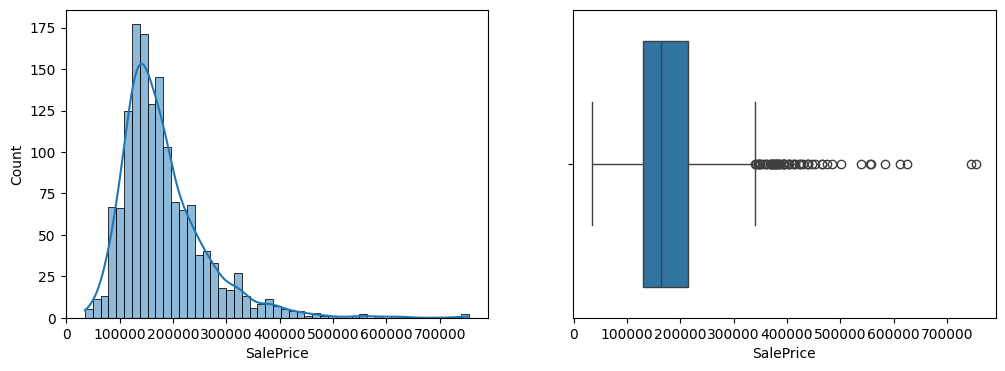

In [6]:
#distribuicao assimetrica, cauda longa pra direita
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_train['SalePrice'], kde=True, ax=ax[0])
sns.boxplot(x=df_train['SalePrice'], ax=ax[1])
plt.show()

In [7]:
df_full.dtypes.value_counts()

str        44
int64      26
float64    12
Name: count, dtype: int64

In [8]:
#colunas com valor faltante
nulos = df_full.drop(columns=['SalePrice']).isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
Functional         2
BsmtHalfBath       2
Utilities          2
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1
dtype: int64

In [ ]:
cols_sem_recurso = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]

for col in cols_sem_recurso:
    df_full[col] = df_full[col].fillna('Sem')

In [ ]:
cols_sem_recurso_num = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
                        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                        'BsmtFullBath', 'BsmtHalfBath']

for col in cols_sem_recurso_num:
    df_full[col] = df_full[col].fillna(0)

In [ ]:
#faltantes
df_full['LotFrontage'] = df_full.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
#faltantes moda
cols_moda = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
             'KitchenQual', 'Functional', 'SaleType', 'Electrical']

for col in cols_moda:
    df_full[col] = df_full[col].fillna(df_full[col].mode()[0])

In [ ]:
nulos_restantes = df_full.drop(columns=['SalePrice']).isnull().sum()
nulos_restantes[nulos_restantes > 0]

Series([], dtype: int64)

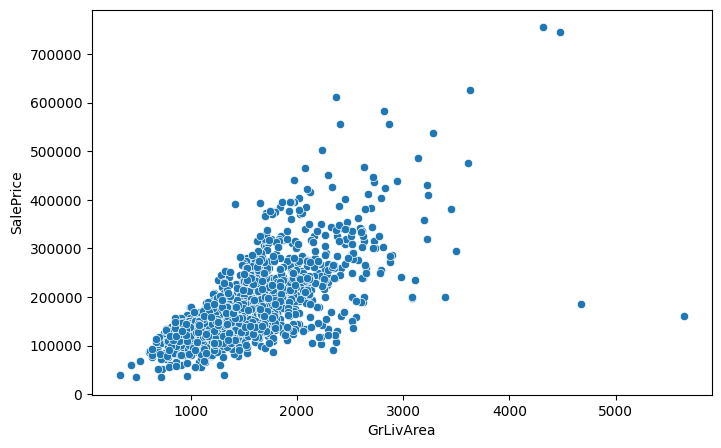

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_train, x='GrLivArea', y='SalePrice')
plt.show()

In [15]:
outliers = df_full[(df_full['GrLivArea'] > 4000) & (df_full['SalePrice'] < 300000)].index
df_full = df_full.drop(index=outliers)

In [ ]:
mapa_qualidade = {'Sem': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

cols_qualidade = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                   'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in cols_qualidade:
    df_full[col] = df_full[col].map(mapa_qualidade)

In [ ]:
df_full['area_total'] = df_full['TotalBsmtSF'] + df_full['1stFlrSF'] + df_full['2ndFlrSF']

In [18]:
#correlacao com o preco, so treino tem SalePrice
df_treino_tratado = df_full[df_full['origem'] == 'treino']

corr = df_treino_tratado.corr(numeric_only=True)[['SalePrice']].sort_values(by='SalePrice', ascending=False)
corr.head(15)

,SalePrice
SalePrice,1.000000
area_total,0.832877
OverallQual,0.795774
GrLivArea,0.734968
ExterQual,0.686756
KitchenQual,0.662236
TotalBsmtSF,0.651153
GarageCars,0.641047
1stFlrSF,0.631530
GarageArea,0.629217


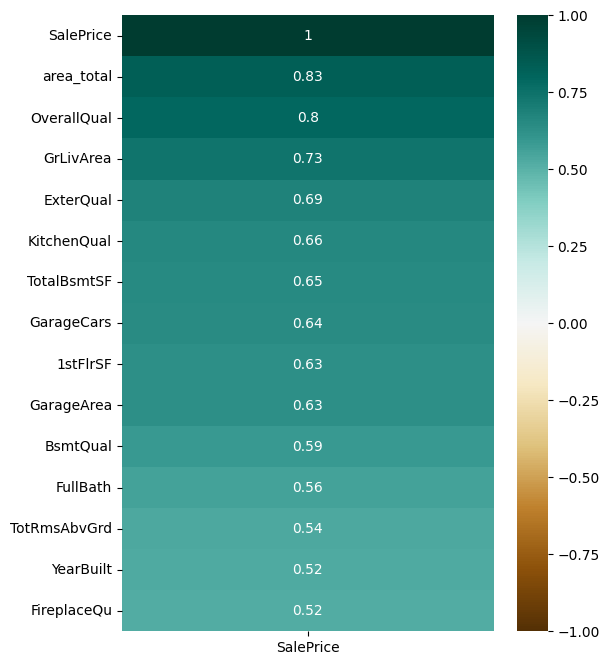

In [19]:
plt.figure(figsize=(6, 8))
sns.heatmap(corr.head(15), annot=True, vmin=-1, vmax=1, cmap='BrBG')
plt.show()

In [ ]:
#categoricas sem ordem one-hot
cols_categoricas = df_full.select_dtypes(include='object').columns.drop('origem')
df_full = pd.get_dummies(df_full, columns=cols_categoricas, dtype='int64')
df_full.shape

C:\Users\Chyi Jaan Li\AppData\Local\Temp\ipykernel_17796\1976723889.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_full.select_dtypes(include='object').columns.drop('origem')


(2917, 268)

In [ ]:
#log no preco pra reduzir assimetria modelo linear
df_full.loc[df_full['origem'] == 'treino', 'SalePrice_log'] = np.log1p(
    df_full.loc[df_full['origem'] == 'treino', 'SalePrice']
)

In [22]:
df_treino = df_full[df_full['origem'] == 'treino'].drop(columns=['origem', 'Id'])
df_teste = df_full[df_full['origem'] == 'teste'].drop(columns=['origem', 'Id', 'SalePrice', 'SalePrice_log'])

x = df_treino.drop(columns=['SalePrice', 'SalePrice_log'])
y = df_treino['SalePrice_log']

x.shape, y.shape

((1458, 265), (1458,))

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=51)

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
#modelo 1, regressao linear simples
model1 = LinearRegression().fit(x_train, y_train)
y_pred = model1.predict(x_test)

model1.score(x_train, y_train)
model1.score(x_test, y_test)

0.9187851405647844

In [26]:
mean_absolute_error(y_test, y_pred)

0.08526470860274116

In [27]:
mean_squared_error(y_test, y_pred) ** 0.5

0.12134635869709065

In [28]:
#modelo 2, ridge, regularizada, ajuda com tantas colunas do one-hot
model2 = Ridge(alpha=10).fit(x_train, y_train)
y_pred = model2.predict(x_test)

model2.score(x_train, y_train)
model2.score(x_test, y_test)

0.9317143780993279

In [29]:
mean_absolute_error(y_test, y_pred)

0.07800627000537934

In [30]:
mean_squared_error(y_test, y_pred) ** 0.5

0.11126885904286107

In [31]:
#modelo 3, lasso
model3 = Lasso(alpha=0.001).fit(x_train, y_train)
y_pred = model3.predict(x_test)

model3.score(x_train, y_train)
model3.score(x_test, y_test)

C:\Users\Chyi Jaan Li\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.106008e-01, tolerance: 1.796e-02
  model = cd_fast.enet_coordinate_descent(


0.9308501473546407

In [32]:
mean_absolute_error(y_test, y_pred)

0.07977760963531344

In [33]:
mean_squared_error(y_test, y_pred) ** 0.5

0.11197076097522388

In [ ]:
#modelo 4, random forest, nao linear, interacao entre variaveis
model4 = RandomForestRegressor(n_estimators=300, random_state=51).fit(x_train, y_train)
y_pred = model4.predict(x_test)

model4.score(x_train, y_train)
model4.score(x_test, y_test)

0.8927661907853156

In [35]:
mean_absolute_error(y_test, y_pred)

0.09733782742261887

In [36]:
mean_squared_error(y_test, y_pred) ** 0.5

0.1394359843790136

In [37]:
#comparacao dos 4 pelo r2 de teste
r2_linear = model1.score(x_test, y_test)
r2_ridge = model2.score(x_test, y_test)
r2_lasso = model3.score(x_test, y_test)
r2_forest = model4.score(x_test, y_test)

r2_linear, r2_ridge, r2_lasso, r2_forest

(0.9187851405647844,
 0.9317143780993279,
 0.9308501473546407,
 0.8927661907853156)

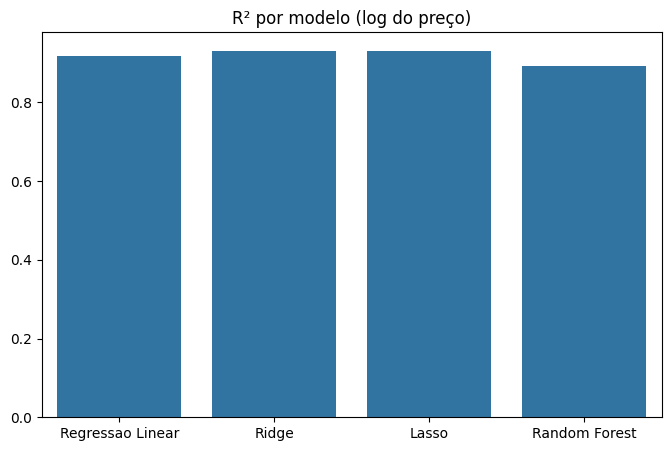

In [38]:
nomes_modelos = ['Regressao Linear', 'Ridge', 'Lasso', 'Random Forest']
r2_modelos = [r2_linear, r2_ridge, r2_lasso, r2_forest]

plt.figure(figsize=(8, 5))
sns.barplot(x=nomes_modelos, y=r2_modelos)
plt.title('R² por modelo (log do preço)')
plt.show()